In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [68]:
# xsec
file_xsec = "/home/zhe2/data/PACE/svd_retrieval_output/interim_20250702T184325_svd_retrieval_full_gpu.nc"
ds_xsec   = xr.open_dataset(file_xsec)
# svd
file_svd = "/home/zhe2/data/PACE/svd_retrieval_output/interim_20250702T184325_svd_retrieval_full_gpu.nc"
ds_svd   = xr.open_dataset(file_svd)
# L2AOP - nflh
l2aop = "/home/zhe2/data/PACE/L2_AOP_V3.1/PACE_OCI.20250702T184325.L2.OC_AOP.V3_1.nc"
dtr_l2aop = xr.open_datatree(l2aop)
ds_l2aop = xr.merge(dtr_l2aop.to_dict().values())


/tmp/ipykernel_2661537/4290115934.py:9: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dtr_l2aop = xr.open_datatree(l2aop)


In [69]:
# nflh
nflh = ds_l2aop['nflh'].values
lat  = ds_l2aop['latitude'].values
lon  = ds_l2aop['longitude'].values

# sif_svd
sif_678_svd = ds_svd['sif_radiance_678nm'].values
lat_sif_svd = ds_svd['latitude'].values
lon_sif_svd = ds_svd['longitude'].values

# sif_xsec
sif_678_xsec = ds_xsec['sif_radiance_678nm'].values
lat_sif_xsec = ds_xsec['latitude'].values
lon_sif_xsec = ds_xsec['longitude'].values


In [70]:
ds_svd

<xarray.Dataset> Size: 285MB
Dimensions:             (scans: 1709, pixels: 1272, state: 23, sif_nev: 1)
Dimensions without coordinates: scans, pixels, state, sif_nev
Data variables: (12/16)
    latitude            (scans, pixels) float32 9MB -15.33 -15.31 ... 7.553 7.56
    longitude           (scans, pixels) float32 9MB -96.21 -96.15 ... -75.87
    x_hat               (state, scans, pixels) float32 200MB ...
    converged           (scans, pixels) uint8 2MB ...
    status_code         (scans, pixels) int16 4MB ...
    n_steps             (scans, pixels) int16 4MB ...
    ...                  ...
    sif_coeffs          (sif_nev, scans, pixels) float32 9MB ...
    sif_radiance_678nm  (scans, pixels) float32 9MB 0.06655 0.1303 ... 0.01523
    is_dark             (scans, pixels) uint8 2MB ...
    is_ocean            (scans, pixels) uint8 2MB ...
    source_pixel_index  (pixels) int32 5kB ...
    source_scan_index   (scans) int32 7kB ...
Attributes:
    title:            PACE SVD transmittance retrieval swath output
    retrieval_type:   svd
    history:          Created 2026-05-18T00:38:53
    input_pace_file:  /home/zhe2/data/PACE/svd_retrieval_interim/interim_2025...
    config_file:      /home/zhe2/FraLab/PACE_redSIF_PACE/configs/global_fit_p...
    state_names_csv:  pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_1...
    pixel_start:      1
    pixel_end:        1272
    scan_start:       1
    scan_end:         1709

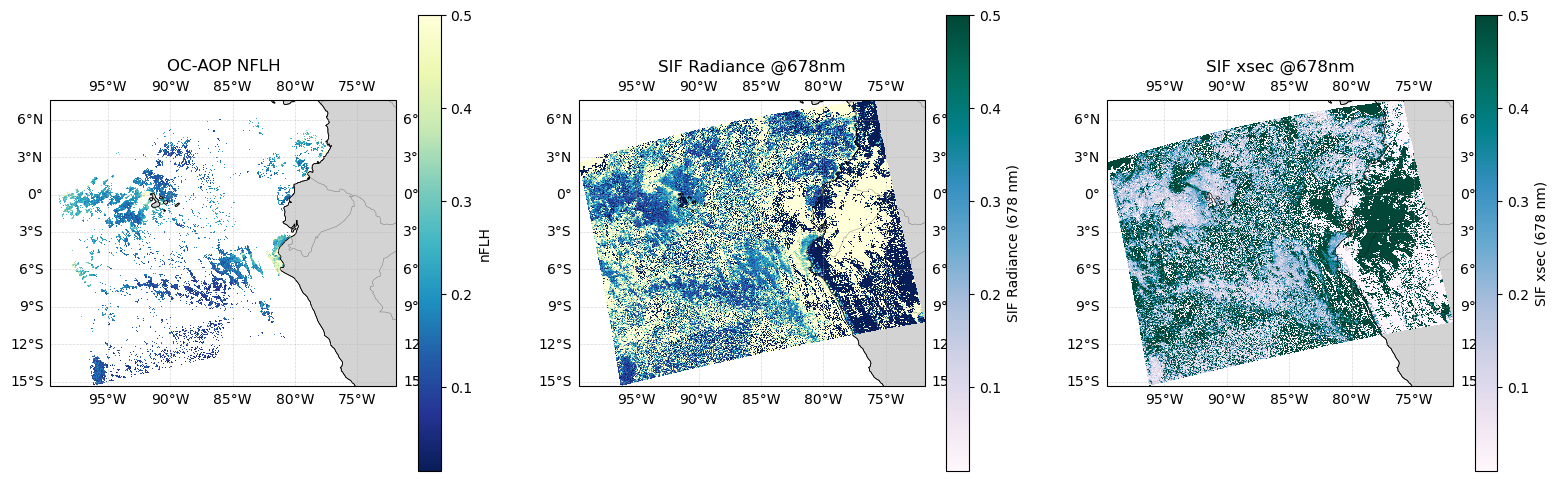

In [71]:
# Plot nflh and SIF radiance with common Cartopy map, adapted from overlapping_tropomi.ipynb (9-32)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

extent = [
    np.nanmin(lon), np.nanmax(lon),
    np.nanmin(lat), np.nanmax(lat)
]

vmin = 0.01
vmax = .5

# ---- NFLH panel ----
ax = axes[0]
ax.set_extent(extent, crs=ccrs.PlateCarree())
mesh_nflh = ax.pcolormesh(lon, lat, nflh, transform=ccrs.PlateCarree(),
                          cmap="YlGnBu_r", vmin=vmin, vmax=vmax)
ax.set_title("OC-AOP NFLH")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# ---- SIF radiance panel ----
ax = axes[1]
ax.set_extent(extent, crs=ccrs.PlateCarree())
mesh_sif = ax.pcolormesh(lon_sif_svd, lat_sif_svd, sif_678_svd, transform=ccrs.PlateCarree(),
                         cmap="YlGnBu_r", vmin=vmin, vmax=vmax)
ax.set_title("SIF Radiance @678nm")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# ---- SIF xsec panel ----
ax = axes[2]
ax.set_extent(extent, crs=ccrs.PlateCarree())
mesh_sif = ax.pcolormesh(lon_sif_xsec, lat_sif_xsec, sif_678_xsec, transform=ccrs.PlateCarree(),
                         cmap="PuBuGn", vmin=vmin, vmax=vmax)
ax.set_title("SIF xsec @678nm")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

plt.tight_layout()

# Optionally, add colorbars for each panel
cbar1 = fig.colorbar(mesh_nflh, ax=axes[0], orientation='vertical', shrink=0.8, label='nFLH')
cbar2 = fig.colorbar(mesh_sif, ax=axes[1], orientation='vertical', shrink=0.8, label='SIF Radiance (678 nm)')
cbar3 = fig.colorbar(mesh_sif, ax=axes[2], orientation='vertical', shrink=0.8, label='SIF xsec (678 nm)')

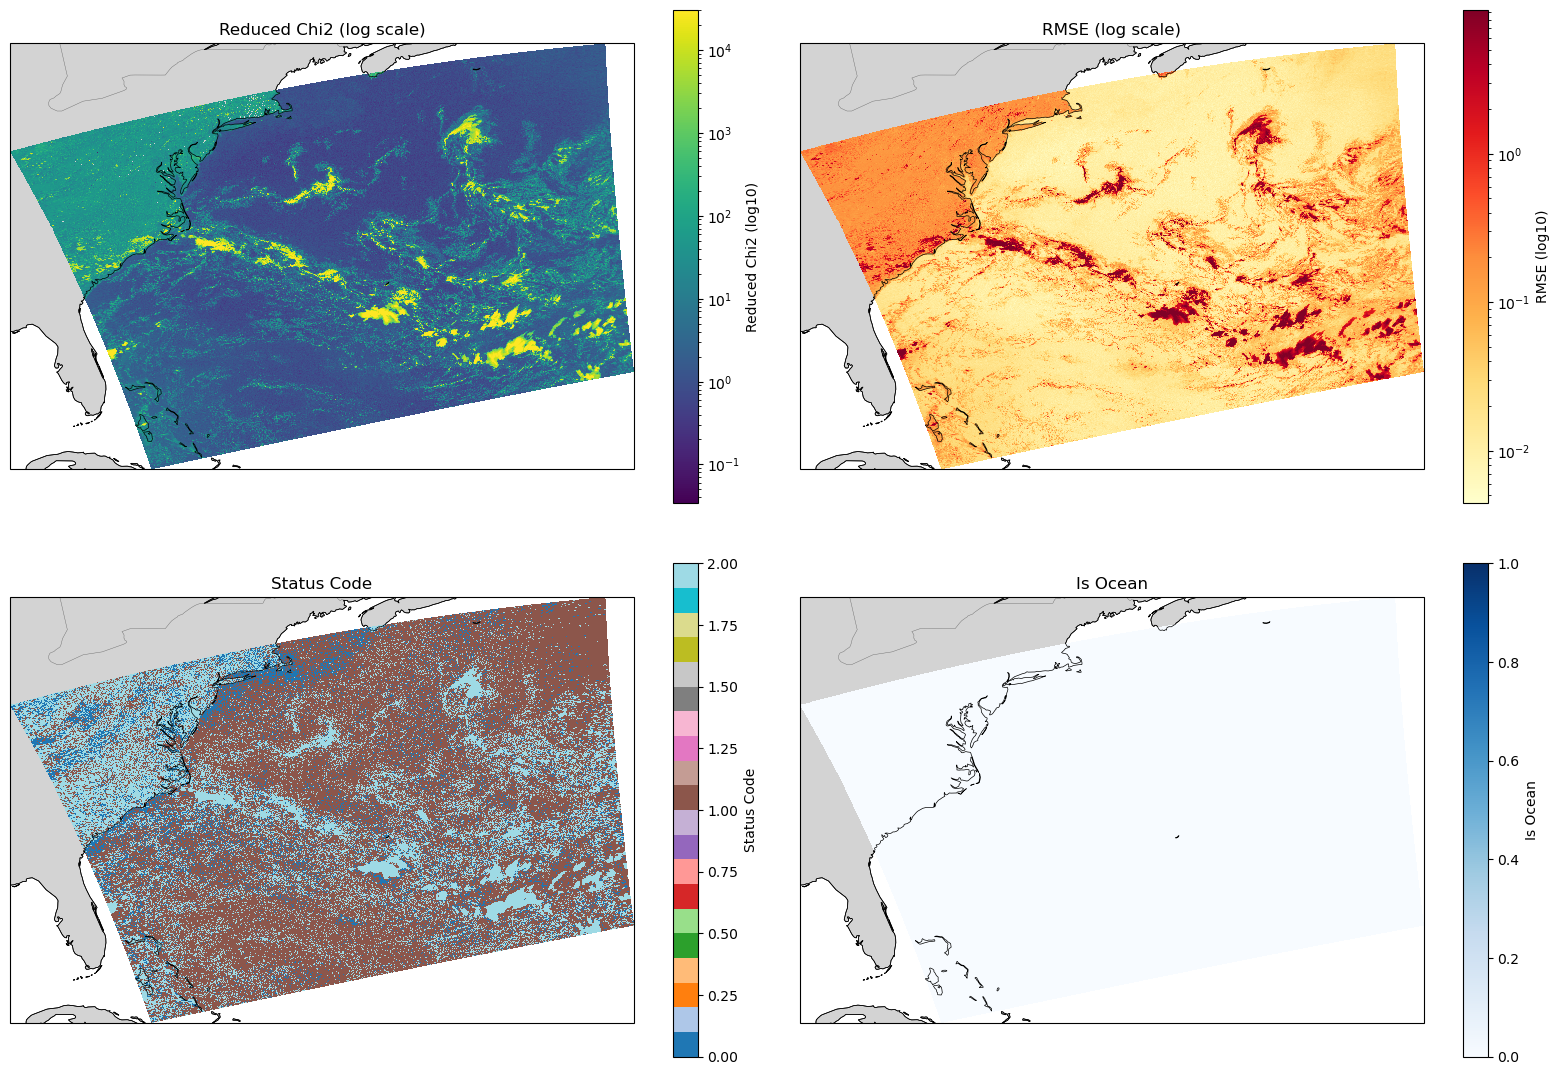

In [45]:
# Plot reducedChi2 (logNorm), rmse (logNorm), status code, and is_ocean spatially using pcolormesh on lat/lon from ds_svd, in a 2x2 grid
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Reduced Chi2, plotted in LogNorm
reduced_chi2_data = ds_svd['reduced_chi2'].values
min_rchi2 = np.nanmin(reduced_chi2_data[reduced_chi2_data > 0])
vmin_rchi2 = max(min_rchi2, 1e-2)
vmax_rchi2 = np.nanpercentile(reduced_chi2_data, 99)
im0 = axes[0, 0].pcolormesh(
    ds_svd['longitude'],
    ds_svd['latitude'],
    reduced_chi2_data,
    cmap='viridis',
    shading='auto',
    norm=LogNorm(vmin=vmin_rchi2, vmax=vmax_rchi2),
    transform=ccrs.PlateCarree()
)
axes[0, 0].set_title('Reduced Chi2 (log scale)')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
axes[0, 0].add_feature(cfeature.COASTLINE, linewidth=0.5)
axes[0, 0].add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
cbar0 = fig.colorbar(im0, ax=axes[0, 0], orientation='vertical', shrink=0.8, label='Reduced Chi2 (log10)')

# RMSE (LogNorm)
rmse_data = ds_svd['rmse'].values
min_rmse = np.nanmin(rmse_data[rmse_data > 0])
vmin_rmse = max(min_rmse, 1e-4)
vmax_rmse = np.nanpercentile(rmse_data, 99)
im1 = axes[0, 1].pcolormesh(
    ds_svd['longitude'],
    ds_svd['latitude'],
    rmse_data,
    cmap='YlOrRd',
    shading='auto',
    norm=LogNorm(vmin=vmin_rmse, vmax=vmax_rmse),
    transform=ccrs.PlateCarree()
)
axes[0, 1].set_title('RMSE (log scale)')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')
axes[0, 1].add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
axes[0, 1].add_feature(cfeature.COASTLINE, linewidth=0.5)
axes[0, 1].add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
cbar1 = fig.colorbar(im1, ax=axes[0, 1], orientation='vertical', shrink=0.8, label='RMSE (log10)')

# Status code panel (int, with discrete colormap)
status_code_data = ds_svd['status_code'].values
im2 = axes[1, 0].pcolormesh(
    ds_svd['longitude'],
    ds_svd['latitude'],
    status_code_data,
    cmap='tab20',
    shading='auto',
    vmin=np.nanmin(status_code_data),
    vmax=np.nanmax(status_code_data),
    transform=ccrs.PlateCarree()
)
axes[1, 0].set_title('Status Code')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')
axes[1, 0].add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
axes[1, 0].add_feature(cfeature.COASTLINE, linewidth=0.5)
axes[1, 0].add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
cbar2 = fig.colorbar(im2, ax=axes[1, 0], orientation='vertical', shrink=0.8, label='Status Code')

# is_ocean panel
is_ocean_data = ds_svd['is_ocean'].values
im3 = axes[1, 1].pcolormesh(
    ds_svd['longitude'],
    ds_svd['latitude'],
    is_ocean_data,
    cmap='Blues',
    shading='auto',
    vmin=0,
    vmax=1,
    transform=ccrs.PlateCarree()
)
axes[1, 1].set_title('Is Ocean')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
axes[1, 1].add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
axes[1, 1].add_feature(cfeature.COASTLINE, linewidth=0.5)
axes[1, 1].add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
cbar3 = fig.colorbar(im3, ax=axes[1, 1], orientation='vertical', shrink=0.8, label='Is Ocean')

plt.tight_layout()
plt.show()


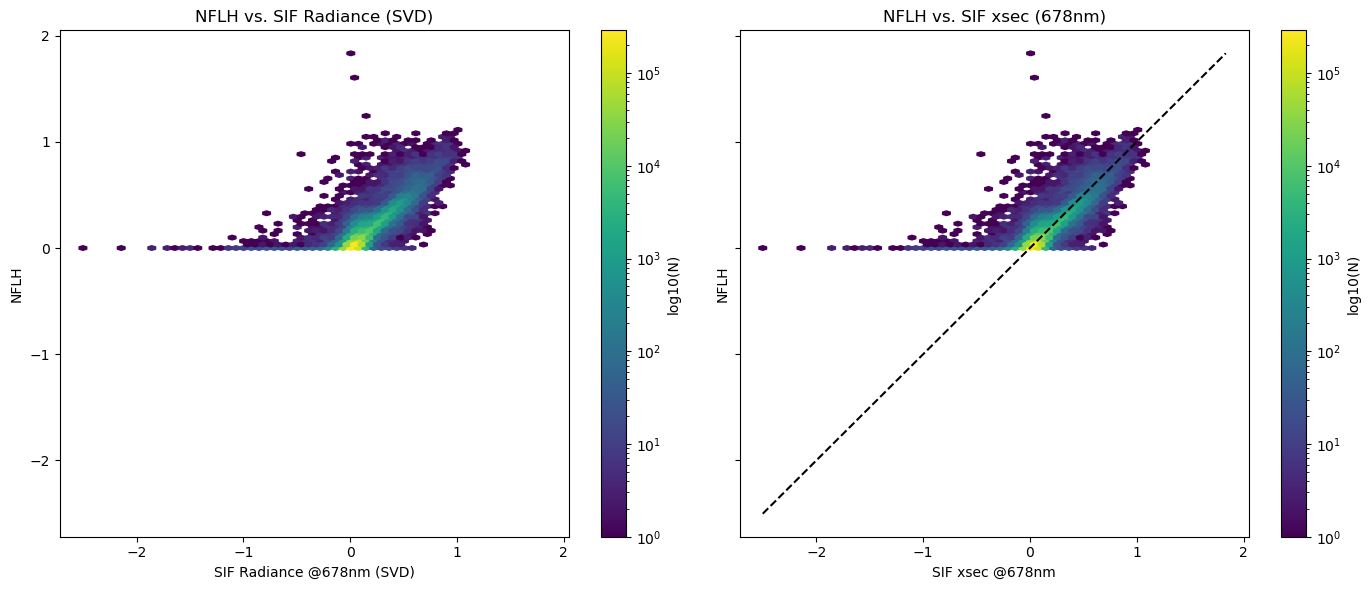

In [46]:
# Side-by-side scatterplots: nflh vs. sif_678_svd and nflh vs. sif_678 (xsec)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# First plot: nflh vs. sif_678_svd (remove NaN from either)
x1 = sif_678_svd.flatten()
y1 = nflh.flatten()
valid_mask1 = ~np.isnan(x1) & ~np.isnan(y1)
x1_valid = x1[valid_mask1]
y1_valid = y1[valid_mask1]
hb1 = axes[0].hexbin(x1_valid, y1_valid, gridsize=50, cmap='viridis', bins='log')
axes[0].set_xlabel('SIF Radiance @678nm (SVD)')
axes[0].set_ylabel('NFLH')
axes[0].set_title('NFLH vs. SIF Radiance (SVD)')
cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label('log10(N)')

# Second plot: nflh vs. sif_678 (from xsec, remove NaN from either)
x2 = sif_678_xsec.flatten()
y2 = nflh.flatten()
valid_mask2 = ~np.isnan(x2) & ~np.isnan(y2)
x2_valid = x2[valid_mask2]
y2_valid = y2[valid_mask2]
if x2_valid.size > 0 and y2_valid.size > 0:
    axes[1].plot([min(x2_valid.min(), y2_valid.min()), max(x2_valid.max(), y2_valid.max())],
                 [min(x2_valid.min(), y2_valid.min()), max(x2_valid.max(), y2_valid.max())],
                 'k--', label='1:1 line', zorder=10)
hb2 = axes[1].hexbin(x2_valid, y2_valid, gridsize=50, cmap='viridis', bins='log')
axes[1].set_xlabel('SIF xsec @678nm')
axes[1].set_ylabel('NFLH')
axes[1].set_title('NFLH vs. SIF xsec (678nm)')
cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label('log10(N)')

plt.tight_layout()
plt.show()


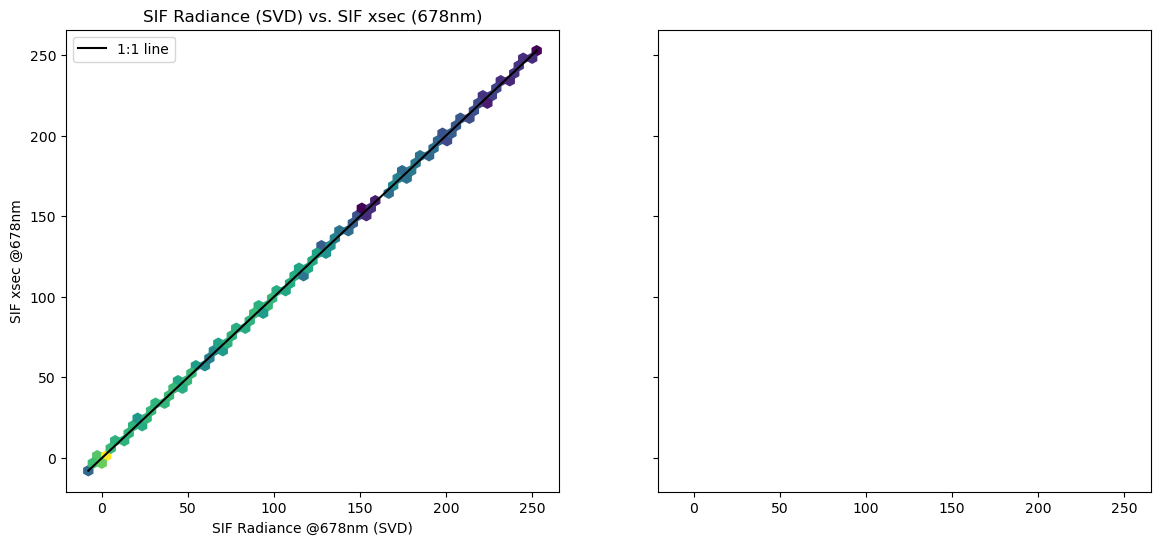

In [ ]:
# svd vs. xsec
x1 = sif_678_svd.flatten()
x2 = sif_678_xsec.flatten()
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# First plot: sif_678_svd vs. sif_678_xsec
axes[0].hexbin(x1, x2, gridsize=50, cmap='viridis', bins='log')
axes[0].set_xlabel('SIF Radiance @678nm (SVD)')
axes[0].set_ylabel('SIF xsec @678nm')
axes[0].set_title('SIF Radiance (SVD) vs. SIF xsec (678nm)')

# To make sure the 1:1 line displays, it must span the same range on both axes
min_val = min(x1.min(), x2.min())
max_val = max(x1.max(), x2.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k-', label='1:1 line', zorder=10)

# Optionally, you can also bring the line to the front and add a legend to ensure it's visible:
axes[0].legend()

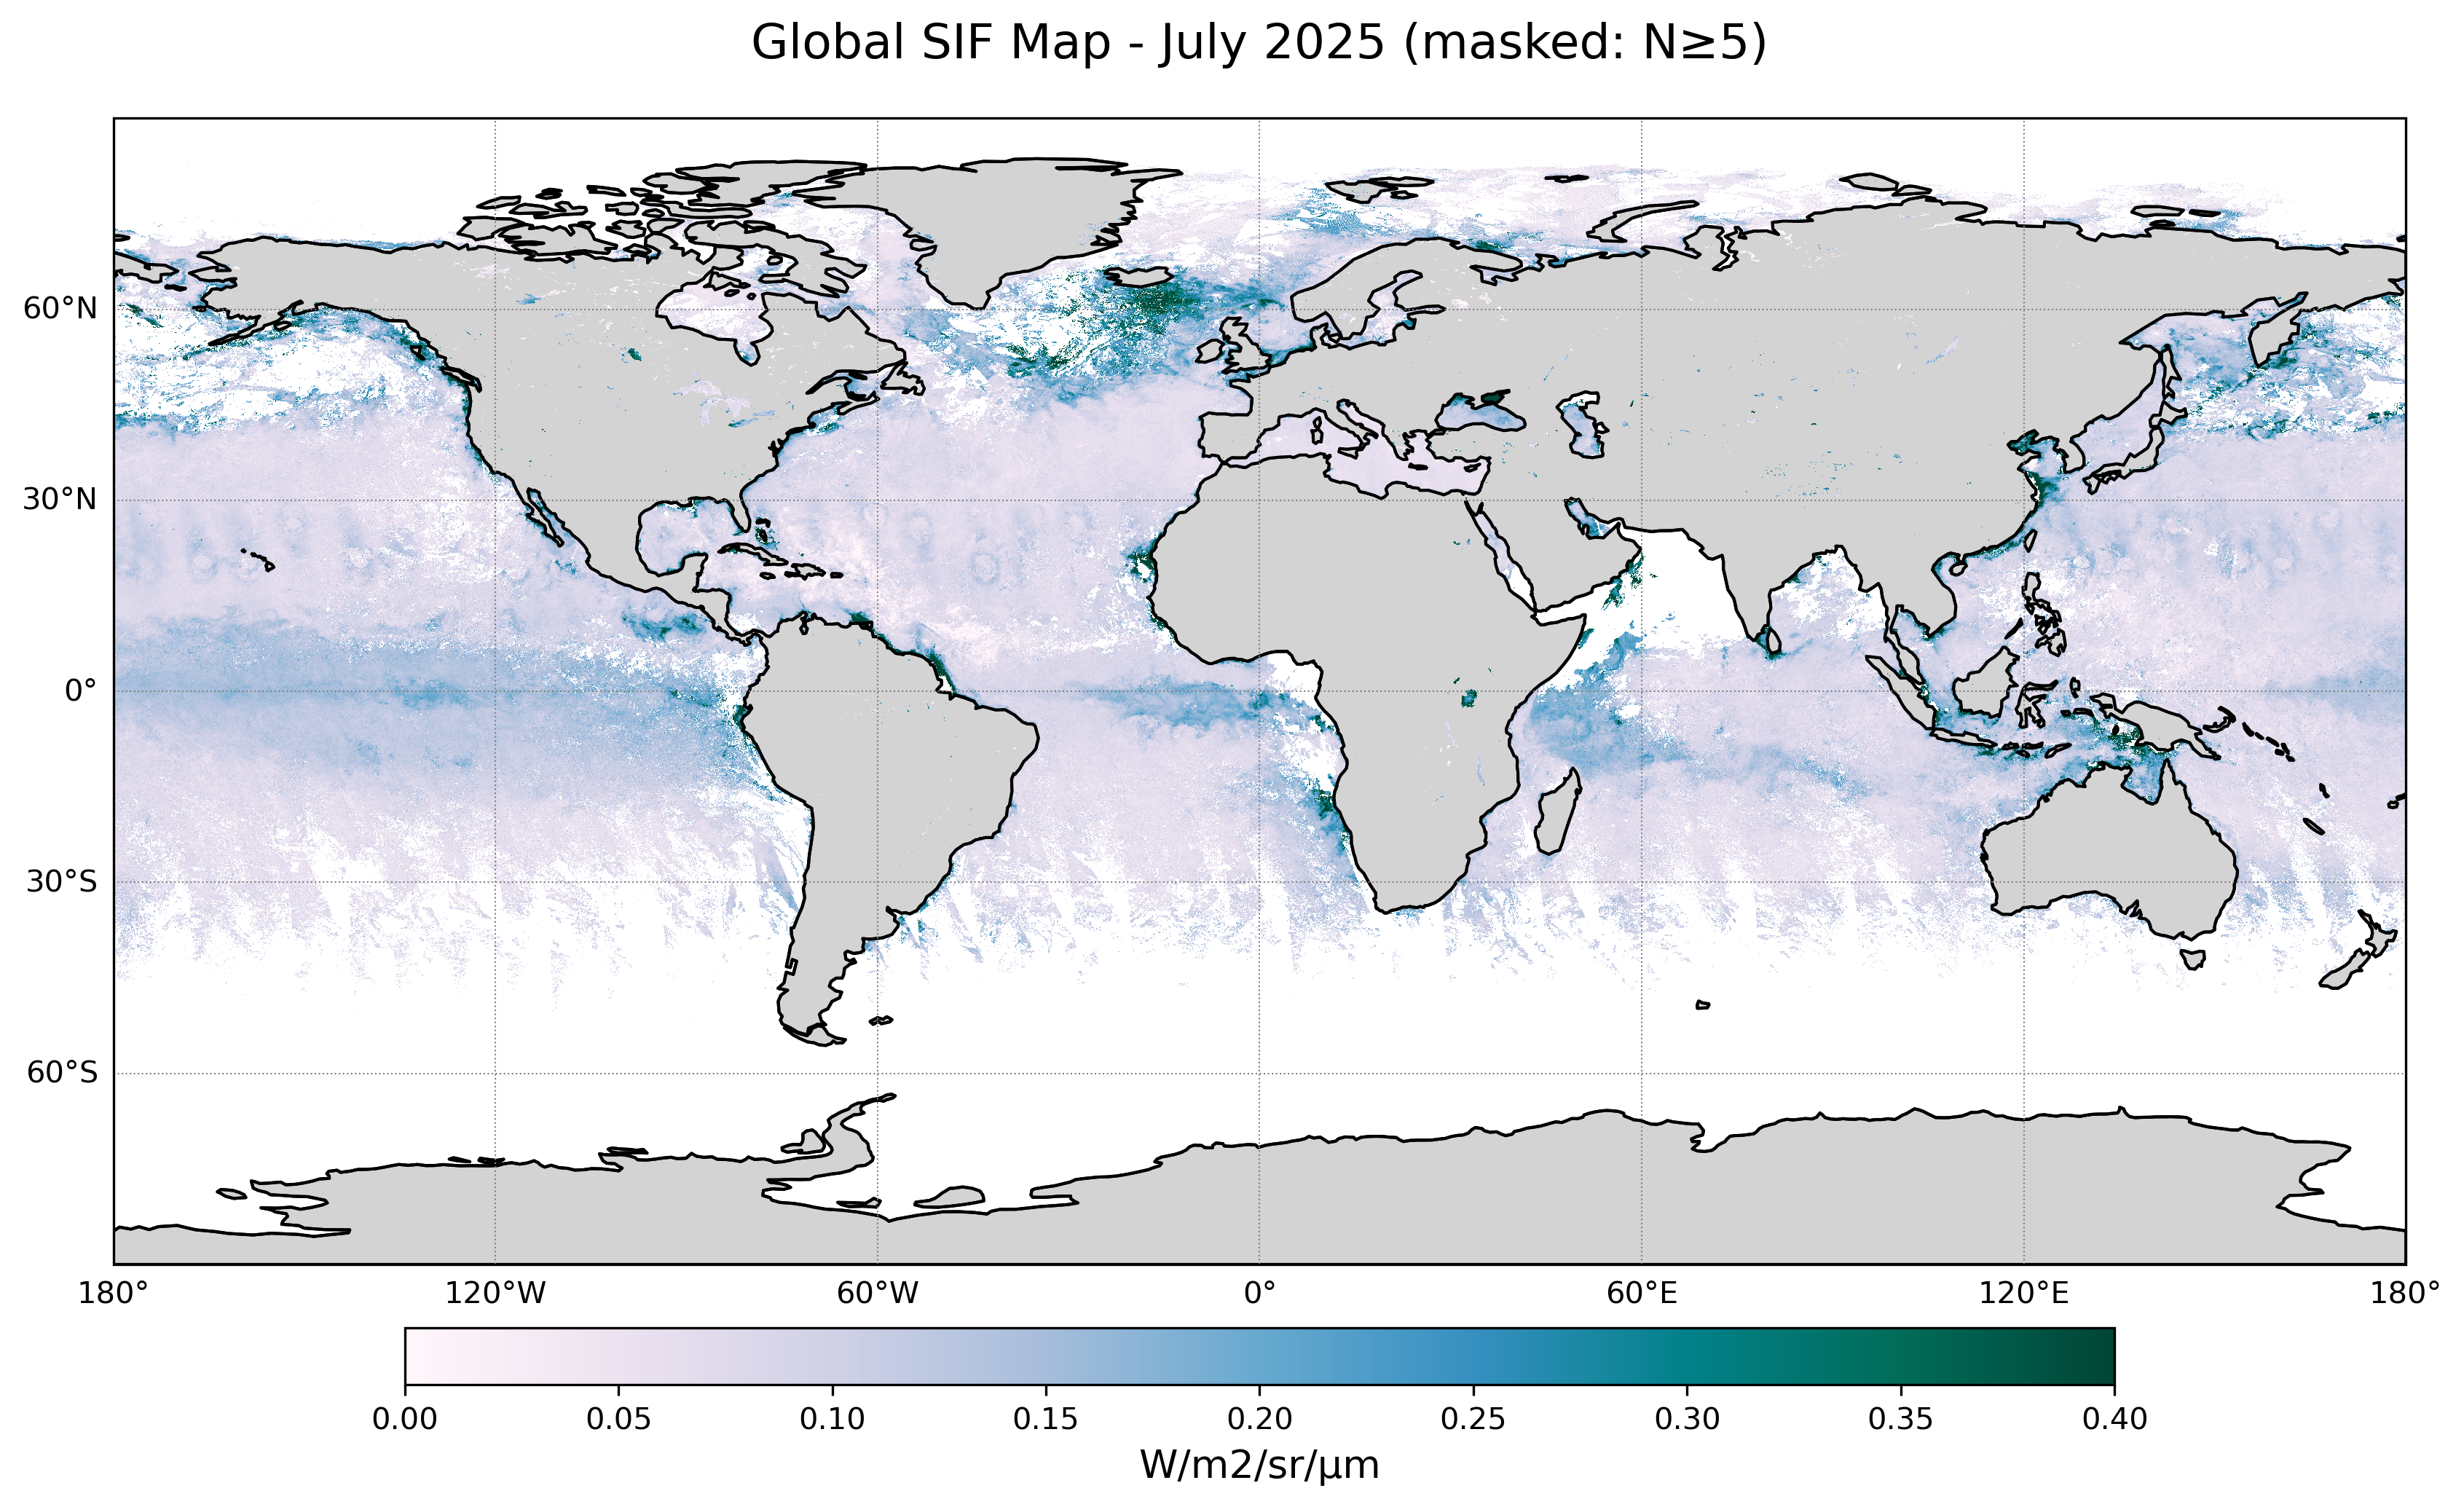

In [10]:
# Read raster
file_raster = "/home/zhe2/data/PACE/svd_rasterized/sif678_raster_20250630_20250730_0p1deg_partial.nc"
ds_raster = xr.open_dataset(file_raster)

# Prepare data for plotting
lon = ds_raster['lon']
lat = ds_raster['lat']
sif = ds_raster['sif_radiance_678nm'].values
counts = ds_raster['counts'].values

# Mask pixels with counts < 5
import numpy as np
sif_masked = np.ma.masked_where(counts < 0, sif)

# Robust import of cartopy for global map features
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    has_cartopy = True
except ImportError:
    has_cartopy = False

if has_cartopy:
    # Use PlateCarree for map so left/right edges wrap
    fig, ax = plt.subplots(figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300)
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
    # Add features
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgrey')
    # ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='azure')
    # ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=1)

    # Gridlines with lon/lat labels, only left/bottom
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle=':')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Plot SIF with a visually enhanced colormap and color range
    sif_cmap = plt.get_cmap('PuBuGn')
    pcm = ax.pcolormesh(lon, lat, sif_masked, cmap=sif_cmap, vmin=0., vmax=0.4, 
                        transform=ccrs.PlateCarree(), shading='auto')

    # Enhanced colorbar
    cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, fraction=0.045, aspect=30)
    cb.set_label('W/m2/sr/µm', fontsize=13)
    cb.outline.set_linewidth(0.8)
    cb.ax.tick_params(labelsize=10)

    # Add a nice title
    ax.set_title('Global SIF Map - July 2025 (masked: N≥5)', fontsize=16, pad=20)

    plt.tight_layout()
    plt.show()
else:
    # Fallback: regular matplotlib plot if cartopy is missing
    plt.figure(figsize=(15, 7))
    pcm = plt.pcolormesh(lon, lat, sif_masked, cmap='winter', vmin=0., vmax=0.4, shading='auto')
    plt.colorbar(pcm, label='W/m2/sr/µm')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Global SIF Map - July 2025 (masked: N≥5)')
    plt.tight_layout()
    plt.show()


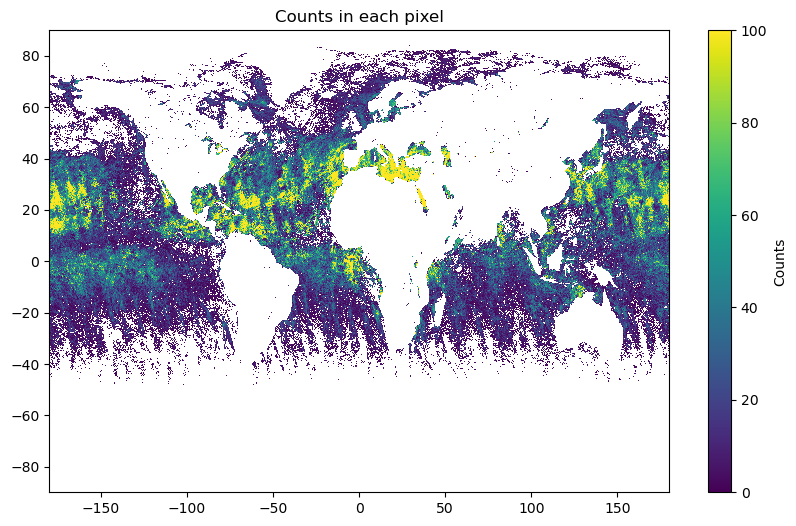

In [8]:
# counts in each pixels
counts = ds_raster['counts'].values
fig, ax = plt.subplots(figsize=(10, 6))
ax.pcolormesh(lon, lat, counts, cmap='viridis', vmin=0, vmax=100)
ax.set_title('Counts in each pixel')
plt.colorbar(ax.pcolormesh(lon, lat, counts, cmap='viridis', vmin=0, vmax=100), ax=ax, label='Counts')
plt.show()


In [ ]:
# obtain monthly nflh from PACE L3
import earthaccess
from datetime import datetime

earthaccess.login()

start_date = datetime(2025, 7, 1)
end_date   = datetime(2025, 7, 31)

results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_FLH",
    temporal=(start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d")),
)

results = [r for r in results if "4km" in r.data_links()[0]]
results = [r for r in results if "8D" in r.data_links()[0]]

/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [ ]:
fo  = earthaccess.open(granules=[results[0]])
ds0 = xr.open_dataset(fo[0])
ds0

/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/earthaccess/store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 889.75it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.66s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 27594.11it/s]


<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    nflh     (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20250626_20250703.L3m.8D.FLH....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/FLH/3.1
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         12548815
    data_minimum:                      -3.499132e-05
    data_maximum:                      4.9717846

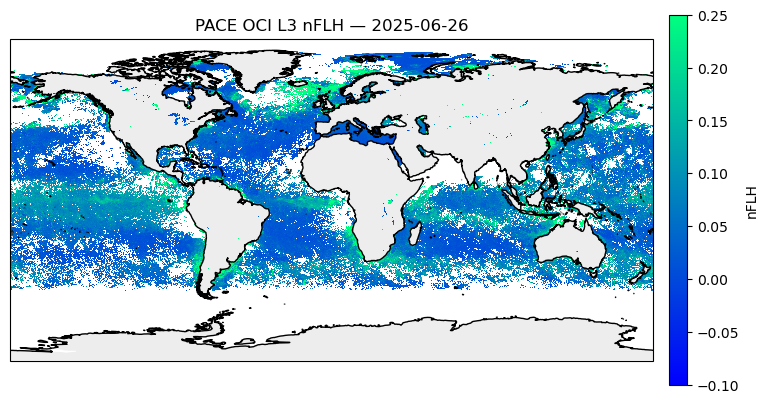

In [ ]:
# ── Plot single-granule chlorophyll over the North Atlantic ──────────
nflh    = ds0['nflh']
lon     = ds0['lon']
lat     = ds0['lat']

fig, ax = plt.subplots(figsize=(10, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
mesh = ax.pcolormesh(
    lon, lat, nflh,
    cmap="winter", transform=ccrs.PlateCarree(),
    vmin=-0.1, vmax=.25
)
ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4)
plt.colorbar(mesh, ax=ax, label="nFLH",
             orientation='vertical', pad=0.02, shrink=0.8)
ax.set_title(f"PACE OCI L3 nFLH — {results[0]['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime'][:10]}")
plt.show()